In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Load feature-engineered dataset
df = pd.read_csv(
    "creditcard_feature_engineered.csv"
)

print("Dataset Shape:", df.shape)

# Remove categorical Time_Period for baseline model
# Keep numerical features
df_model = df.drop(columns=["Time_Period"])

print("\nModel Dataset Shape:", df_model.shape)

# Separate features and target
X = df_model.drop(columns=["Class"])
y = df_model["Class"]

print("\nFeatures Shape:", X.shape)
print("Target Shape:", y.shape)

print("\nClass Distribution:")
print(y.value_counts())

Dataset Shape: (283726, 34)

Model Dataset Shape: (283726, 33)

Features Shape: (283726, 32)
Target Shape: (283726,)

Class Distribution:
Class
0    283253
1       473
Name: count, dtype: int64


In [2]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

print("\nTraining Class Distribution:")
print(y_train.value_counts())

print("\nTesting Class Distribution:")
print(y_test.value_counts())

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFeature scaling completed.")
print("Scaled Training Shape:", X_train_scaled.shape)
print("Scaled Testing Shape:", X_test_scaled.shape)

Training Data: (226980, 32)
Testing Data: (56746, 32)

Training Class Distribution:
Class
0    226602
1       378
Name: count, dtype: int64

Testing Class Distribution:
Class
0    56651
1       95
Name: count, dtype: int64

Feature scaling completed.
Scaled Training Shape: (226980, 32)
Scaled Testing Shape: (56746, 32)


In [3]:
model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully!")
y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

print("\nPredictions generated successfully.")
print("Number of predictions:", len(y_pred))

Logistic Regression model trained successfully!

Predictions generated successfully.
Number of predictions: 56746


In [4]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_proba)

print("Baseline Model Performance")
print("=" * 40)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

# Detailed classification report
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Genuine", "Fraud"],
        zero_division=0
    )
)

Baseline Model Performance
Accuracy : 0.9747
Precision: 0.0551
Recall   : 0.8737
F1 Score : 0.1036
ROC-AUC  : 0.9683

Confusion Matrix:
[[55227  1424]
 [   12    83]]

Classification Report:
              precision    recall  f1-score   support

     Genuine       1.00      0.97      0.99     56651
       Fraud       0.06      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.55     56746
weighted avg       1.00      0.97      0.99     56746



In [5]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

models = {
    "Decision Tree": DecisionTreeClassifier(
        max_depth=8,
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        max_depth=12,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    )
}

trained_models = {}

for name, model in models.items():
    print(f"\nTraining {name}...")

    model.fit(X_train, y_train)

    trained_models[name] = model

    print(f"{name} trained successfully.")

print("\nAll additional models trained successfully!")


Training Decision Tree...
Decision Tree trained successfully.

Training Random Forest...
Random Forest trained successfully.

Training Gradient Boosting...
Gradient Boosting trained successfully.

All additional models trained successfully!


In [6]:
results = []

# Add Logistic Regression
all_models = {
    "Logistic Regression": model,
    **trained_models
}

for name, clf in all_models.items():

    # Logistic Regression uses scaled data
    if name == "Logistic Regression":
        predictions = clf.predict(X_test_scaled)
        probabilities = clf.predict_proba(X_test_scaled)[:, 1]

    # Tree-based models use original data
    else:
        predictions = clf.predict(X_test)
        probabilities = clf.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(
            y_test, predictions, zero_division=0
        ),
        "Recall": recall_score(
            y_test, predictions, zero_division=0
        ),
        "F1 Score": f1_score(
            y_test, predictions, zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_test, probabilities
        )
    })

# Create comparison DataFrame
results_df = pd.DataFrame(results)

# Round values
results_df[
    ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
] = results_df[
    ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
].round(4)

print("Model Performance Comparison:")
display(
    results_df.sort_values(
        by="ROC-AUC",
        ascending=False
    ).reset_index(drop=True)
)

c:\Users\Amaan\OneDrive\Desktop\real-time-financial-fraud-detection\.venv\Lib\site-packages\sklearn\utils\validation.py:2830: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(
c:\Users\Amaan\OneDrive\Desktop\real-time-financial-fraud-detection\.venv\Lib\site-packages\sklearn\utils\validation.py:2830: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(


Model Performance Comparison:


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,0.9993,0.8372,0.7579,0.7956,0.9672
1,Decision Tree,0.9915,0.1410,0.8000,0.2397,0.9074
2,Gradient Boosting,0.9992,0.8611,0.6526,0.7425,0.8539
3,Logistic Regression,0.9985,0.5679,0.4842,0.5227,0.6772


In [7]:
logistic_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

# Train Logistic Regression
logistic_model.fit(X_train_scaled, y_train)

print("Logistic Regression retrained successfully!")


# Store all models correctly
all_models = {
    "Logistic Regression": logistic_model,
    "Decision Tree": trained_models["Decision Tree"],
    "Random Forest": trained_models["Random Forest"],
    "Gradient Boosting": trained_models["Gradient Boosting"]
}
results = []

for name, clf in all_models.items():

    if name == "Logistic Regression":
        predictions = clf.predict(X_test_scaled)
        probabilities = clf.predict_proba(X_test_scaled)[:, 1]

    else:
        predictions = clf.predict(X_test)
        probabilities = clf.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(
            y_test, predictions, zero_division=0
        ),
        "Recall": recall_score(
            y_test, predictions, zero_division=0
        ),
        "F1 Score": f1_score(
            y_test, predictions, zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_test, probabilities
        )
    })


results_df = pd.DataFrame(results)

metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC"
]

results_df[metric_columns] = results_df[metric_columns].round(4)

print("\nCorrected Model Performance Comparison:")
display(results_df)

Logistic Regression retrained successfully!

Corrected Model Performance Comparison:


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.9747,0.0551,0.8737,0.1036,0.9683
1,Decision Tree,0.9915,0.1410,0.8000,0.2397,0.9074
2,Random Forest,0.9993,0.8372,0.7579,0.7956,0.9672
3,Gradient Boosting,0.9992,0.8611,0.6526,0.7425,0.8539


In [8]:
for name, clf in all_models.items():

    if name == "Logistic Regression":
        predictions = clf.predict(X_test_scaled)
    else:
        predictions = clf.predict(X_test)

    print(f"\n{name}")
    print("-" * 40)
    print(confusion_matrix(y_test, predictions))


Logistic Regression
----------------------------------------
[[55227  1424]
 [   12    83]]

Decision Tree
----------------------------------------
[[56188   463]
 [   19    76]]

Random Forest
----------------------------------------
[[56637    14]
 [   23    72]]

Gradient Boosting
----------------------------------------
[[56641    10]
 [   33    62]]


In [9]:
print("Baseline Model Summary")
print("=" * 60)

print("\nDataset:")
print(f"Training samples : {X_train.shape[0]}")
print(f"Testing samples  : {X_test.shape[0]}")
print(f"Features         : {X_train.shape[1]}")

print("\nModel Performance:")
display(results_df)

print("\nKey Observation:")
print("- Logistic Regression achieves high recall but very low precision.")
print("- Decision Tree improves precision but still produces many false positives.")
print("- Random Forest provides a strong balance between precision and recall.")
print("- Gradient Boosting has high precision but lower recall.")

Baseline Model Summary

Dataset:
Training samples : 226980
Testing samples  : 56746
Features         : 32

Model Performance:


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.9747,0.0551,0.8737,0.1036,0.9683
1,Decision Tree,0.9915,0.1410,0.8000,0.2397,0.9074
2,Random Forest,0.9993,0.8372,0.7579,0.7956,0.9672
3,Gradient Boosting,0.9992,0.8611,0.6526,0.7425,0.8539



Key Observation:
- Logistic Regression achieves high recall but very low precision.
- Decision Tree improves precision but still produces many false positives.
- Random Forest provides a strong balance between precision and recall.
- Gradient Boosting has high precision but lower recall.


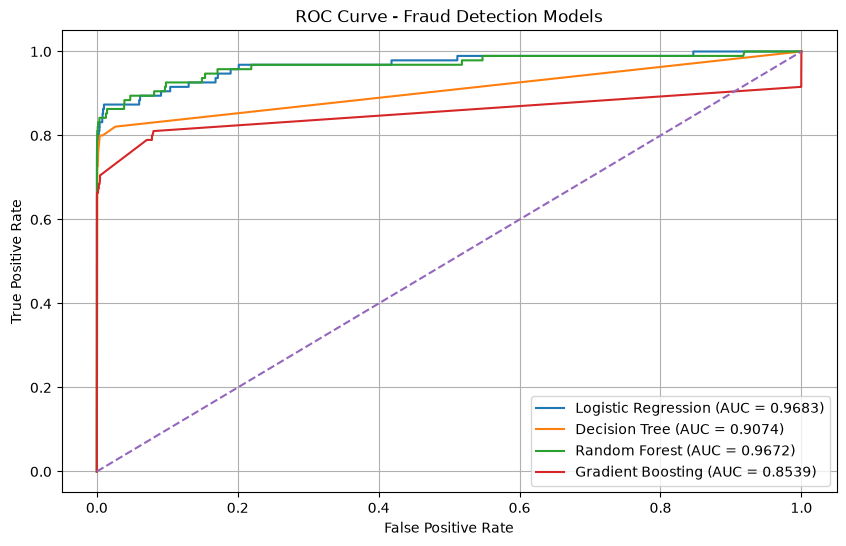

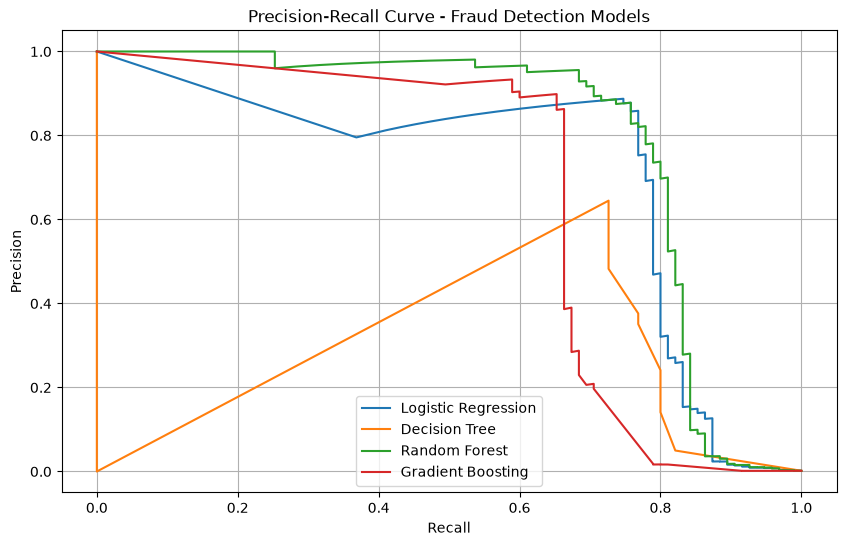

In [10]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for name, clf in all_models.items():

    if name == "Logistic Regression":
        probabilities = clf.predict_proba(X_test_scaled)[:, 1]
    else:
        probabilities = clf.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, probabilities)
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {roc_auc:.4f})"
    )

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Fraud Detection Models")
plt.legend()
plt.grid(True)
plt.show()

from sklearn.metrics import precision_recall_curve

plt.figure(figsize=(10, 6))

for name, clf in all_models.items():

    if name == "Logistic Regression":
        probabilities = clf.predict_proba(X_test_scaled)[:, 1]
    else:
        probabilities = clf.predict_proba(X_test)[:, 1]

    precision, recall, _ = precision_recall_curve(
        y_test,
        probabilities
    )

    plt.plot(
        recall,
        precision,
        label=name
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Fraud Detection Models")
plt.legend()
plt.grid(True)
plt.show()

In [11]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Select Random Forest
final_model = all_models["Random Forest"]

# Predictions
y_pred_final = final_model.predict(X_test)
y_proba_final = final_model.predict_proba(X_test)[:, 1]

# Metrics
final_accuracy = accuracy_score(y_test, y_pred_final)
final_precision = precision_score(y_test, y_pred_final)
final_recall = recall_score(y_test, y_pred_final)
final_f1 = f1_score(y_test, y_pred_final)
final_roc_auc = roc_auc_score(y_test, y_proba_final)

print("FINAL RANDOM FOREST EVALUATION")
print("=" * 50)

print(f"Accuracy  : {final_accuracy:.4f}")
print(f"Precision : {final_precision:.4f}")
print(f"Recall    : {final_recall:.4f}")
print(f"F1 Score  : {final_f1:.4f}")
print(f"ROC-AUC   : {final_roc_auc:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_final))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_final,
    target_names=["Genuine", "Fraud"]
))

FINAL RANDOM FOREST EVALUATION
Accuracy  : 0.9993
Precision : 0.8372
Recall    : 0.7579
F1 Score  : 0.7956
ROC-AUC   : 0.9672

Confusion Matrix:
[[56637    14]
 [   23    72]]

Classification Report:
              precision    recall  f1-score   support

     Genuine       1.00      1.00      1.00     56651
       Fraud       0.84      0.76      0.80        95

    accuracy                           1.00     56746
   macro avg       0.92      0.88      0.90     56746
weighted avg       1.00      1.00      1.00     56746



In [12]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": final_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Top 15 Important Features:")
display(feature_importance.head(15))

Top 15 Important Features:


,Feature,Importance
14,V14,0.177989
12,V12,0.135851
10,V10,0.128044
4,V4,0.097701
17,V17,0.092937
11,V11,0.050010
16,V16,0.049032
7,V7,0.038293
3,V3,0.036977
2,V2,0.020564


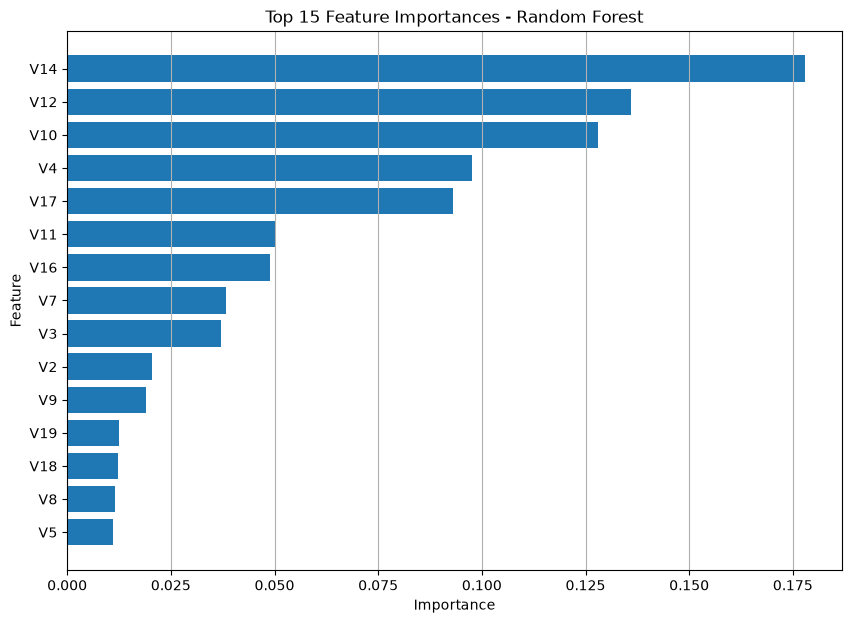

In [13]:
top_features = feature_importance.head(15).sort_values(
    by="Importance"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances - Random Forest")
plt.grid(axis="x")
plt.show()

In [14]:
import os
import joblib

os.makedirs("../models", exist_ok=True)

joblib.dump(
    final_model,
    "../models/random_forest_baseline.pkl"
)

joblib.dump(
    scaler,
    "../models/scaler.pkl"
)

joblib.dump(
    X_train.columns.tolist(),
    "../models/feature_columns.pkl"
)

print("Baseline Random Forest model saved successfully!")
print("Saved files:")
print("- models/random_forest_baseline.pkl")
print("- models/scaler.pkl")
print("- models/feature_columns.pkl")

Baseline Random Forest model saved successfully!
Saved files:
- models/random_forest_baseline.pkl
- models/scaler.pkl
- models/feature_columns.pkl
